In [13]:
#import data set, pandas and matplotlib for data viz options
import pandas as pd
#sets display so printed output rows aren't truncated
pd.set_option('display.max_rows', None)
import matplotlib.pyplot as plt
df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/refs/heads/master/311_Service_Requests_from_2019May.csv')

/tmp/ipykernel_1132/3786168790.py:6: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/refs/heads/master/311_Service_Requests_from_2019May.csv')


In [14]:
#How many rows and columns of data?
df.shape

(69637, 21)

In [15]:
#What information is contained in this data set?
df.columns


Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Complaint Type',
       'Location Type', 'Incident Zip', 'Incident Address', 'Street Name',
       'Address Type', 'City', 'Landmark', 'Facility Type', 'Status',
       'Due Date', 'Resolution Description', 'BBL', 'Borough', 'Latitude',
       'Longitude', 'Location'],
      dtype='object')

In [16]:
#preview what the dataframe looks like, take a look at first five rows
df.head()


,Unique Key,Created Date,Closed Date,Agency,Complaint Type,Location Type,Incident Zip,Incident Address,Street Name,Address Type,City,Landmark,Facility Type,Status,Due Date,Resolution Description,BBL,Borough,Latitude,Longitude,Location
0,42680103,5/1/2019 0:00,5/16/2019 21:45,DEP,Water System,NaN,11420.0,127-16 111 AVENUE,111 AVENUE,ADDRESS,South Ozone Park,NaN,NaN,Closed,NaN,The Department of Environment Protection inspe...,4.116320e+09,QUEENS,40.682565,-73.814060,"(40.682565064146196, -73.81406015056832)"
1,42530481,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,10011.0,207 WEST 14 STREET,WEST 14 STREET,ADDRESS,NEW YORK,NaN,NaN,Closed,5/15/2019 22:17,Callers should contact the DOHMH Foodborne Ill...,1.007640e+09,MANHATTAN,40.738791,-74.000224,"(40.738790792032844, -74.00022373020307)"
2,42527619,5/1/2019 0:00,5/13/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,10025.0,2664 BROADWAY,BROADWAY,ADDRESS,NEW YORK,NaN,NaN,Closed,5/15/2019 10:04,The Department of Health and Mental Hygiene wi...,1.018730e+09,MANHATTAN,40.798040,-73.969300,"(40.79804015465285, -73.96930001020544)"
3,42526597,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,11208.0,624 SOUTH CONDUIT BOULEVARD,SOUTH CONDUIT BOULEVARD,ADDRESS,BROOKLYN,NaN,NaN,Closed,5/15/2019 17:27,The Department of Health and Mental Hygiene wi...,3.042380e+09,BROOKLYN,40.675905,-73.866660,"(40.67590510222738, -73.86665990579837)"
4,42526595,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,11106.0,31-91 21 STREET,21 STREET,ADDRESS,Astoria,NaN,NaN,Closed,5/15/2019 17:12,The Department of Health and Mental Hygiene wi...,4.005540e+09,QUEENS,40.765367,-73.931540,"(40.76536704921336, -73.93154011254339)"


In [17]:
#how many overall complaints by Borough, order by number of complaints descending
df.groupby(['Borough']) ['Borough'].size().sort_values(ascending=False)

,Borough
Borough,
BROOKLYN,22247
QUEENS,18623
MANHATTAN,13133
BRONX,10925
STATEN ISLAND,3848
Unspecified,861


In [18]:
#What percentage of complaints does each Borough have?
df["Borough"].value_counts(normalize=True) * 100

,proportion
Borough,
BROOKLYN,31.947097
QUEENS,26.742967
MANHATTAN,18.859227
BRONX,15.688499
STATEN ISLAND,5.525798
Unspecified,1.236412


In [19]:
#determine if we want to drop the unspecified boroughs. What percentage of total does that represent?
861/69637

0.012364116777000732

In [20]:
#Since the Unspecified Borough represents 1.2% of the complaints, let's drop
df.drop(df[df['Borough'] == 'Unspecified'].index, inplace=True)

In [21]:
#Relevevant summary statistics: What is the Borough with the most complaints?
max_complaint = df['Borough'].value_counts().idxmax()
complaint_count = df['Borough'].value_counts().max()

print(f"The Borough with the most complaints '{max_complaint}' with {complaint_count} occurrences.")


The Borough with the most complaints 'BROOKLYN' with 22247 occurrences.


In [22]:
#Relevevant summary statistics: What is the Borough with the least complaints?
min_complaint = df['Borough'].value_counts().idxmin()
complaint_count = df['Borough'].value_counts().min()

print(f"The Borough with the least complaints '{min_complaint}' with {complaint_count} occurrences.")


The Borough with the least complaints 'STATEN ISLAND' with 3848 occurrences.


In [23]:
#Relevant summary statistics - What was the Borough with the median number of complaints?
# Count all of the complaints
complaint_counts = df['Borough'].value_counts()

# What is the middle index position?
middle_index = len(complaint_counts) // 2

# Get complaint name and count at middle position
median_borough = complaint_counts.index[middle_index]
median_count = complaint_counts.iloc[middle_index]

print(f"The Borough with the median number of complaints is '{median_borough}' with {median_count} occurrences.")

The Borough with the median number of complaints is 'MANHATTAN' with 13133 occurrences.


In [24]:
#what are the complaint types, how many of each, and order by number of complaints descending
df.groupby(['Complaint Type']).size().sort_values(ascending=False)

,0
Complaint Type,
Noise - Residential,5828
Request Large Bulky Item Collection,5301
Illegal Parking,5247
Blocked Driveway,3390
Street Condition,3045
HEAT/HOT WATER,2755
Street Light Condition,2268
Noise - Street/Sidewalk,1862
UNSANITARY CONDITION,1809


In [25]:
#Relevevant summary statistics: Which complaint was made the most often?
max_complaint = df['Complaint Type'].value_counts().idxmax()
complaint_count = df['Complaint Type'].value_counts().max()

print(f"The most common complaint is '{max_complaint}' with {complaint_count} occurrences.")


The most common complaint is 'Noise - Residential' with 5828 occurrences.


In [26]:
#Relevant summary statistics: Which complaint was made the least often?
min_complaint = df['Complaint Type'].value_counts().idxmin()
complaint_count_min = df['Complaint Type'].value_counts().min()

print(f"The most common complaint is '{min_complaint}' with {complaint_count_min} occurrences.")

#This doesn't return all complaints with 1 occurrence, need to write maybe an IF statement to deal with that scenario


The most common complaint is 'Unsanitary Animal Facility' with 1 occurrences.


In [27]:
#Relevant summary statistics - What was the median complaint?
# Count all of the complaints
complaint_counts = df['Complaint Type'].value_counts()

# What is the middle index position?
middle_index = len(complaint_counts) // 2

# Get complaint name and count at middle position
median_complaint = complaint_counts.index[middle_index]
median_count = complaint_counts.iloc[middle_index]

print(f"The median complaint is '{median_complaint}' with {median_count} occurrences.")

#Resultant number seems really low relative to the min/max,
#this is a surprising result, because the top 10 complaint types registered
#so many more complaints, gives an impression of possibly not many complaints overall
#at first glance.


The median complaint is 'Drug Activity' with 69 occurrences.


In [28]:
#Let's drill down and analyze New Tree Requests. First, preview the data, filtering for only New Tree Requests
df[df['Complaint Type']=='New Tree Request'].head()

,Unique Key,Created Date,Closed Date,Agency,Complaint Type,Location Type,Incident Zip,Incident Address,Street Name,Address Type,City,Landmark,Facility Type,Status,Due Date,Resolution Description,BBL,Borough,Latitude,Longitude,Location
271,42514082,5/1/2019 1:46,NaN,DPR,New Tree Request,NaN,11416.0,101-13 80 STREET,80 STREET,LATLONG,OZONE PARK,NaN,NaN,Open,4/20/2021 1:46,The Department of Parks and Recreation will re...,NaN,QUEENS,40.680268,-73.858308,"(40.68026755072659, -73.85830831229089)"
755,42529433,5/1/2019 7:23,NaN,DPR,New Tree Request,Street,11361.0,32-43 CLEARVIEW EXPRESSWAY,CLEARVIEW EXPRESSWAY,ADDRESS,BAYSIDE,NaN,NaN,Open,4/20/2021 7:23,The Department of Parks and Recreation will re...,4.060430e+09,QUEENS,40.770785,-73.782841,"(40.77078476243085, -73.78284111874946)"
817,42528493,5/1/2019 7:35,NaN,DPR,New Tree Request,Street,10307.0,16 MAIDEN LANE,MAIDEN LANE,ADDRESS,STATEN ISLAND,NaN,NaN,Open,4/20/2021 7:35,The Department of Parks and Recreation will re...,5.080120e+09,STATEN ISLAND,40.517012,-74.238292,"(40.51701161283625, -74.23829172034814)"
826,42529431,5/1/2019 7:37,NaN,DPR,New Tree Request,Street,11201.0,84 FRONT STREET,FRONT STREET,ADDRESS,BROOKLYN,NaN,NaN,Assigned,11/2/2019 10:05,The Department of Parks and Recreation has rev...,3.000518e+09,BROOKLYN,40.702505,-73.989285,"(40.702504581706826, -73.98928482849821)"
829,42523372,5/1/2019 7:38,NaN,DPR,New Tree Request,Street,11201.0,84 FRONT STREET,FRONT STREET,ADDRESS,BROOKLYN,NaN,NaN,Assigned,11/2/2019 10:05,The Department of Parks and Recreation has rev...,3.000518e+09,BROOKLYN,40.702505,-73.989285,"(40.702504581706826, -73.98928482849821)"


In [29]:
#lets look at new tree requests, filtering only the columns that may be useful for analysis
# First, recall what all of our available columns are
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Complaint Type',
       'Location Type', 'Incident Zip', 'Incident Address', 'Street Name',
       'Address Type', 'City', 'Landmark', 'Facility Type', 'Status',
       'Due Date', 'Resolution Description', 'BBL', 'Borough', 'Latitude',
       'Longitude', 'Location'],
      dtype='object')

In [30]:
#choose the most useful columns for New Tree Request analysis, subset into a new dataframe, and preview first 10 rows of result
df2 = df.loc[df['Complaint Type'] == 'New Tree Request', ['Created Date', 'Borough', 'Complaint Type', 'Incident Zip', 'Latitude', 'Longitude']]


df2['Incident Zip'] = pd.to_numeric(df2['Incident Zip'], errors='coerce').astype('Int64') #clean Zipcode column


df2.head(10)




,Created Date,Borough,Complaint Type,Incident Zip,Latitude,Longitude
271,5/1/2019 1:46,QUEENS,New Tree Request,11416,40.680268,-73.858308
755,5/1/2019 7:23,QUEENS,New Tree Request,11361,40.770785,-73.782841
817,5/1/2019 7:35,STATEN ISLAND,New Tree Request,10307,40.517012,-74.238292
826,5/1/2019 7:37,BROOKLYN,New Tree Request,11201,40.702505,-73.989285
829,5/1/2019 7:38,BROOKLYN,New Tree Request,11201,40.702505,-73.989285
954,5/1/2019 8:03,QUEENS,New Tree Request,11363,40.768637,-73.740945
1065,5/1/2019 8:16,QUEENS,New Tree Request,11365,40.743424,-73.789928
1466,5/1/2019 9:09,QUEENS,New Tree Request,11361,40.756109,-73.772869
1547,5/1/2019 9:17,BROOKLYN,New Tree Request,11218,40.644457,-73.982278
1654,5/1/2019 9:30,BROOKLYN,New Tree Request,11235,40.587073,-73.962420


In [31]:
#Group New Tree Requests by Borough

df2.groupby("Borough").size().sort_values(ascending=False)

,0
Borough,
BROOKLYN,352
MANHATTAN,237
QUEENS,216
BRONX,45
STATEN ISLAND,41


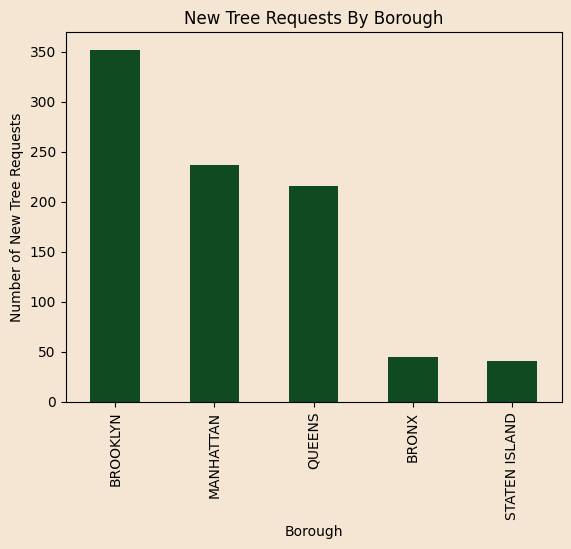

In [32]:
#Visualization 1: bar chart of New Tree Requests By Borough
colors = ['#0f4a21']
ax = df2.groupby("Borough").size().sort_values(ascending=False).plot(kind='bar',
title= 'New Tree Requests By Borough', ylabel='Number of New Tree Requests', xlabel='Borough', color = colors)
ax.set_facecolor('#F5E6D3')
ax.figure.set_facecolor('#F5E6D3');


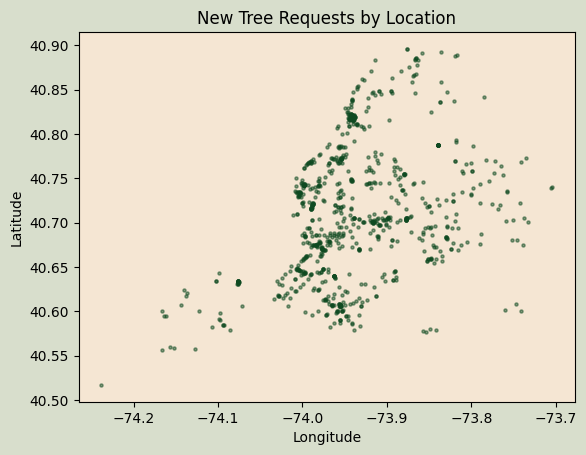

In [33]:
#Visualization 2: Scatter plot of location of New Tree Request, using Latitude and Logitude values.
#I wanted to overlay a map, but it was too comlicated for me at this point.
#However, I was very surprised how plotting by Longitude and Latitude gives
#you the impression of a map, you can kind of see the boroughs from the plot density

plt.figure(facecolor='#d8decc')
plt.scatter(
    df2['Longitude'],
    df2['Latitude'],
    s=5,
    alpha=0.5,
    color = ['#0f4a21']
)

ax = plt.gca()
ax.set_facecolor('#F5E6D3')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('New Tree Requests by Location')

plt.show();




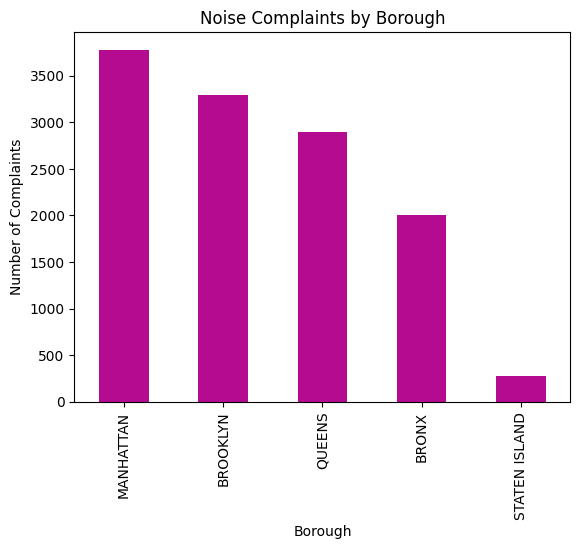

In [35]:
#Visualization 3: Noise complaints by Borough
#All noise complaints by Borough, using fuzzy matching to include
#any type of noise complaint (helicopter, residential, etc.)

df[df['Complaint Type'].str.contains('Noise', na=False)] \
    .groupby('Borough').size().sort_values(ascending=False).plot(
        kind='bar',
        xlabel='Borough',
        ylabel='Number of Complaints',
        title='Noise Complaints by Borough',
        color = '#b50b90',

    );
